#### XAI Analysis

In [1]:
# Install required packages for a fresh notebook runtime.
%pip install -q shap catboost seaborn openpyxl


In [2]:
# Standalone setup for rerunning the XAI notebook directly from Google Drive.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    pass

import pickle
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import Markdown

DRIVE_DATA_PATH = "/content/drive/My Drive/WVS_happiness_study"

X_test_final = pd.read_csv(f"{DRIVE_DATA_PATH}/data/test_sets/X_test_final.csv")
variable_table = pd.read_csv(f"{DRIVE_DATA_PATH}/data/new_questionnaire.csv")


def show_var_details(vars, variable_table, var_ques=False):
    for var in vars:
        if var in variable_table['New Variable Name'].values:
            cond = variable_table['New Variable Name'] == var
            print(f"{var}", variable_table.loc[cond, 'Q_num'].iloc[0])
            if var_ques:
                print(f"Question: {variable_table.loc[cond, 'Var_Name'].iloc[0]}")
        else:
            print(f"{var} not found")
        print('-' * 10)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Markdown

In [4]:
# Load model
import pickle

MODEL_PATH = f"{DRIVE_DATA_PATH}/model/model_ori_data.pkl"
with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)
print(f"Loaded model from {MODEL_PATH}")


Loaded model from /content/drive/My Drive/WVS_happiness_study/model/model_ori_data.pkl


In [5]:
explainer = shap.TreeExplainer(loaded_model)  # assign to an explainer

In [6]:
# X_test_final is a DataFrame
shap_values = explainer.shap_values(X_test_final)

# Sometimes shap_values is a list of two arrays
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # positive class
else:
    shap_values_to_plot = shap_values     # already 2D

Visualise the bar plot for ranking important features.

In [7]:
def plot_shap_bar(shap_values, X, top_n=10, class_idx=1, model_name="Model", save=False):
    """
    Plot ranked SHAP bar plot for tree-based models.

    Parameters:
        shap_values : SHAP values (numpy array or list from TreeExplainer)
        X : pd.DataFrame, features used to compute SHAP
        top_n : int, number of top features to display
        class_idx : int, class index to select (for binary/multi-class)
        model_name : str, title of the plot
    Returns:
        shap_df : pd.DataFrame with mean_abs_shap per feature
    """

    # Handle list output (binary/multi-class)
    if isinstance(shap_values, list):
        shap_values_to_use = shap_values[class_idx]
    else:
        shap_values_to_use = shap_values

    # Flatten if 3D (n_samples, n_features, n_classes)
    if len(shap_values_to_use.shape) > 2:
        shap_values_to_use = shap_values_to_use[:, :, class_idx]

    # Compute mean absolute SHAP values
    mean_abs_shap = np.abs(shap_values_to_use).mean(axis=0)

    # Create DataFrame and select top features
    shap_df = pd.DataFrame({
        "feature": X.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values(by="mean_abs_shap", ascending=False)

    # Normalize for visualization only
    shap_df['scaled_shap'] = shap_df['mean_abs_shap'] / shap_df['mean_abs_shap'].max()
    top_features = shap_df.head(top_n)

    # Plot bar chart
    plt.figure(figsize=(8,5))
    bars = plt.barh(top_features['feature'][::-1], top_features['scaled_shap'][::-1], color='skyblue')
    bars[-1].set_color('dodgerblue')
    plt.xlabel("Scaled Mean |SHAP value|")
    plt.title(f"{model_name} Classifier - Top {top_n} \nFeature Importance")
    if save:
      plt.savefig("/content/drive/My Drive/Colab Notebooks/data/shap_bar.pdf", format="pdf")
    plt.show()

    return shap_df

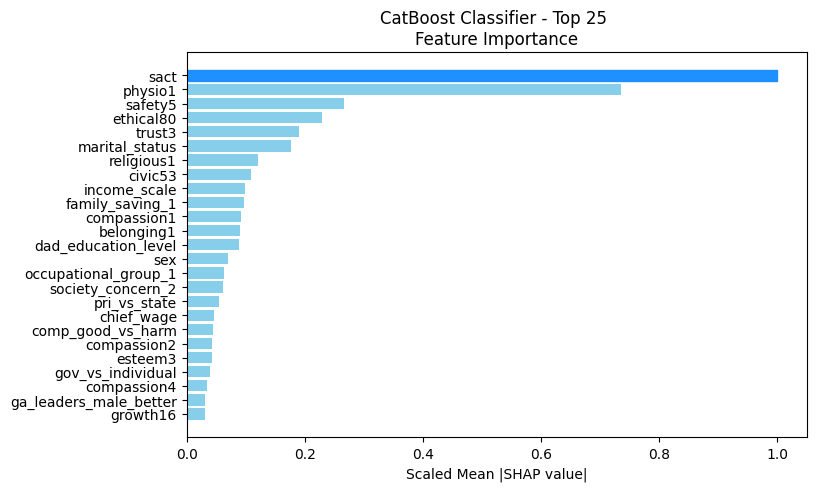

In [8]:
# Bar plot for feature importance
display_feature = 25
overall_best_model_name = 'CatBoost'
shap_df = plot_shap_bar(shap_values, X_test_final,top_n=display_feature, model_name=overall_best_model_name, save=True)

In [9]:
shap_values_exp = shap.Explanation(
    values=shap_values,  # the SHAP values
    data=X_test_final,                    # your original input data
    feature_names=X_test_final.columns if hasattr(X_test_final, "columns") else None
)

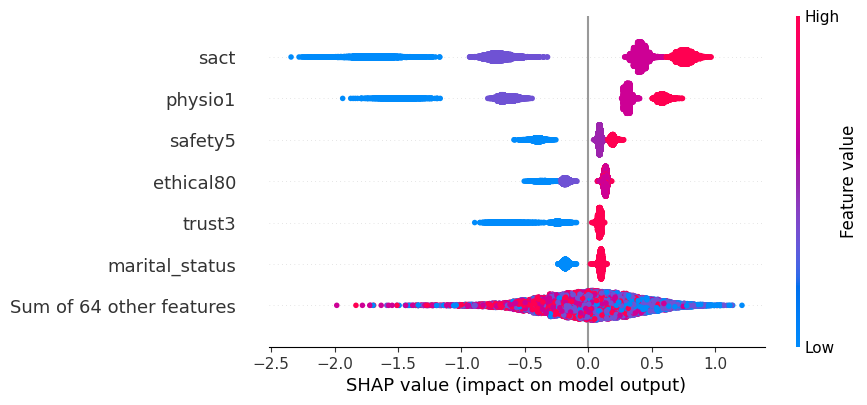

In [10]:
# Compute mean absolute SHAP values
mean_abs = np.abs(shap_values).mean(axis=0)

# Get indices of features sorted ascending (so largest at bottom in beeswarm)
order = np.argsort(mean_abs)

shap.plots.beeswarm(shap_values_exp, max_display=7)

Calculate SHAP weights.

In [11]:
def calculate_shap_weights(shap_values_df, top_n=3):
    """
    Calculate normalized weights based on mean absolute SHAP values.

    Returns:
        weights_normalised : dict of top features with weights summing to 1
    """
    # Compute weights
    shap_values_df["weight"] = shap_values_df["mean_abs_shap"] / shap_values_df["mean_abs_shap"].sum()

    # Select top N features
    top_features = shap_values_df.head(top_n)
    weights_dict = dict(zip(top_features["feature"], top_features["weight"]))

    # Normalize to sum exactly 1
    total = sum(weights_dict.values())
    weights_normalised = {k: round(v/total, 2) for k, v in weights_dict.items()}

    return weights_normalised


Normalise weights.

In [12]:
weights_normalised = calculate_shap_weights(shap_df, top_n=5)

print(weights_normalised)

{'sact': 0.41, 'physio1': 0.3, 'safety5': 0.11, 'ethical80': 0.09, 'trust3': 0.08}


Stratified by Income Scale

In [14]:
def plot_shap_by_income(shap_values, X_test, income_column='income_scale', top_n = 7, save=False):
    """
    Plots a grouped bar chart showing SHAP importance for each income level.

    Parameters:
    - shap_values: The SHAP values array (from explainer.shap_values(X_test))
    - X_test: The dataframe used for testing
    - income_column: The name of your ordinal income column (1-5)
    """

    # 1. Create a dataframe of absolute SHAP values
    # If binary classification, shap_values might be a list; take the second index [1]
    if isinstance(shap_values, list):
        shap_data = pd.DataFrame(np.abs(shap_values[1]), columns=X_test.columns)
    else:
        shap_data = pd.DataFrame(np.abs(shap_values), columns=X_test.columns)

    # 2. Add the income column to this SHAP dataframe to group by it
    shap_data['Income_Level'] = X_test[income_column].values

    # 3. Melt the dataframe for plotting (Long-form)
    melted_shap = shap_data.melt(id_vars='Income_Level', var_name='Feature', value_name='Mean_Abs_SHAP')

    # 4. Group by Income and Feature to get the mean importance
    grouped_shap = melted_shap.groupby(['Income_Level', 'Feature']).mean().reset_index()

    # 5. Filter for the Top n features (based on overall importance) to keep it clean
    top_n_features = grouped_shap.groupby('Feature')['Mean_Abs_SHAP'].mean().nlargest(top_n).index
    final_plot_df = grouped_shap[grouped_shap['Feature'].isin(top_n_features)]

    # 6. Plotting
    plt.figure(figsize=(12, 8))
    sns.barplot(data=final_plot_df, x='Mean_Abs_SHAP', y='Feature', hue='Income_Level', palette='viridis')

    plt.title('SHAP Feature Importance Classified by Income Scale (1-5)', fontsize=15)
    plt.xlabel('Mean |SHAP Value| (Impact on Model Output)')
    plt.ylabel('Top Features')
    plt.legend(title='Income Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save:
        plt.savefig("/content/drive/My Drive/Colab Notebooks/data/shap_by_income.pdf", format="pdf")
    plt.show()

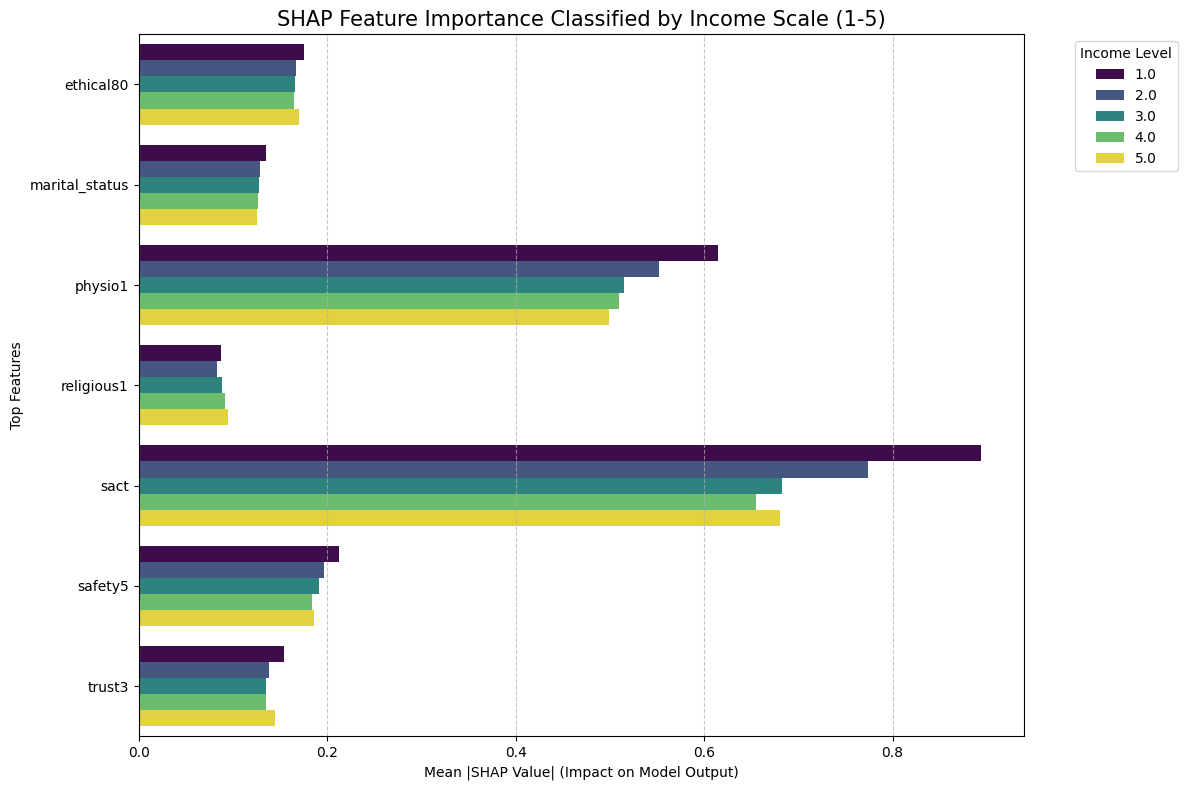

In [15]:
plot_shap_by_income(shap_values, X_test_final, income_column='income_scale', top_n = 7,save=True)

In [16]:
vars = list(weights_normalised.keys())
show_var_details(vars, variable_table, var_ques=True)

sact Q49
Question: Satisfaction with your life
----------
physio1 Q47P
Question: State of health (subjective)
----------
safety5 Q131P
Question: Secure in neighborhood
----------
ethical80 Q253P
Question: Respect for individual human rights nowadays
----------
trust3 Q58P
Question: How much you trust: Your family
----------
